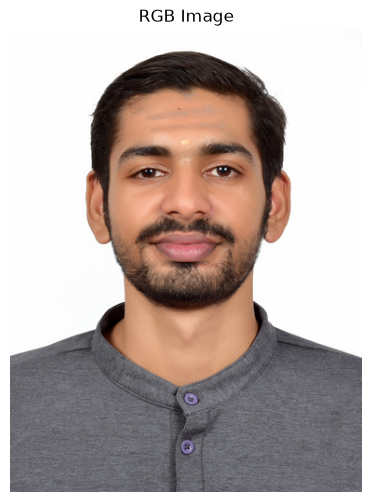

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
# Load image with OpenCV
image_path = r"C:\Users\IIST PC-36\Downloads\Abhiram C N.jpg"
image_bgr = cv2.imread(image_path)

if image_bgr is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

# Convert OpenCV's BGR format to RGB
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


# Visualize the RGB image
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("RGB Image")
plt.axis("off")

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.849066e-08..1.0000001].


Channel means (R, G, B): [175.55847 161.30261 156.52951]
Channel standard deviations (R, G, B): [75.56191  78.11561  80.100044]


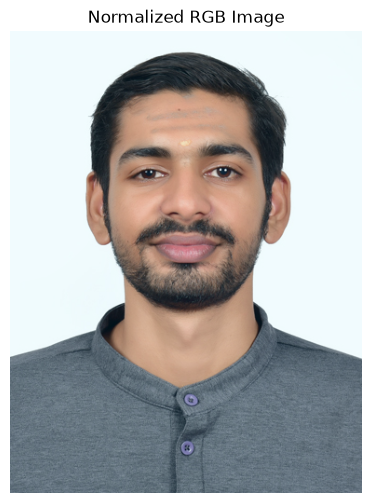

In [10]:
# Calculate channel-wise mean and standard deviation
image_float = image_rgb.astype(np.float32)

channel_means = image_float.mean(axis=(0, 1))
channel_stds = image_float.std(axis=(0, 1))

print("Channel means (R, G, B):", channel_means)
print("Channel standard deviations (R, G, B):", channel_stds)

# Normalize each pixel using its corresponding channel statistics
normalized_image = (image_float - channel_means) / (channel_stds + 1e-8)

# Convert normalized values to a displayable RGB range
display_image = cv2.normalize(
    normalized_image, None, 0, 1, cv2.NORM_MINMAX
)

# Visualize the normalized image
plt.figure(figsize=(8, 6))
plt.imshow(display_image)
plt.title("Normalized RGB Image")
plt.axis("off")
plt.show()

In [11]:
# Print image properties
height, width, channels = image_rgb.shape
total_pixels = height * width

print(f"Dimensions (Height, Width, Channels): ({height}, {width}, {channels})")
print(f"Data type: {image_rgb.dtype}")
print(f"Total pixels: {total_pixels}")

Dimensions (Height, Width, Channels): (496, 378, 3)
Data type: uint8
Total pixels: 187488


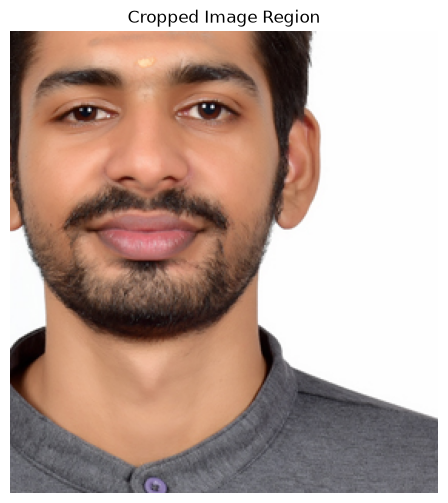

In [12]:
# Select and visualize a cropped region
y_start, y_end = 100, 400
x_start, x_end = 100, 400

cropped_image = image_rgb[y_start:y_end, x_start:x_end]

plt.figure(figsize=(6, 6))
plt.imshow(cropped_image)
plt.title("Cropped Image Region")
plt.axis("off")
plt.show()

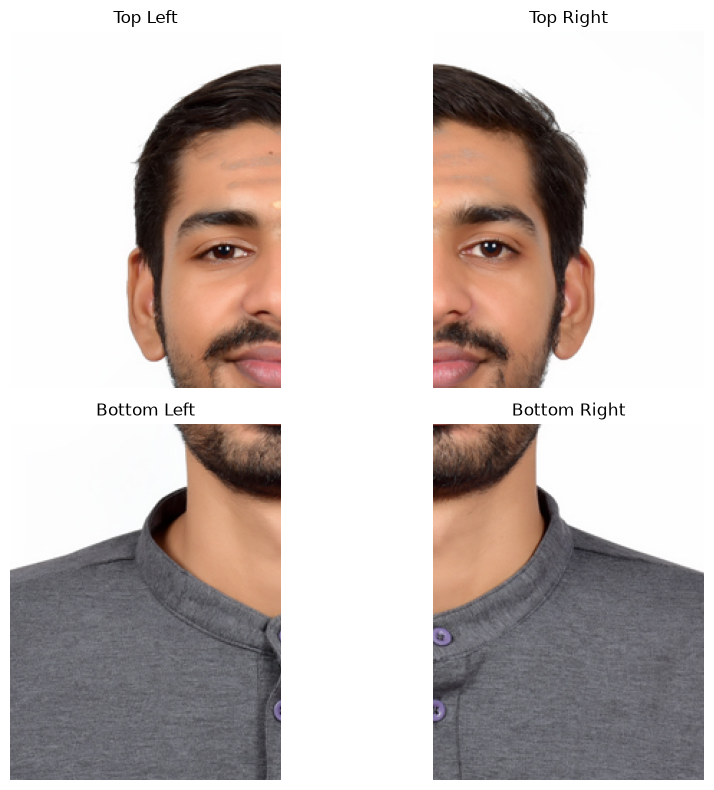

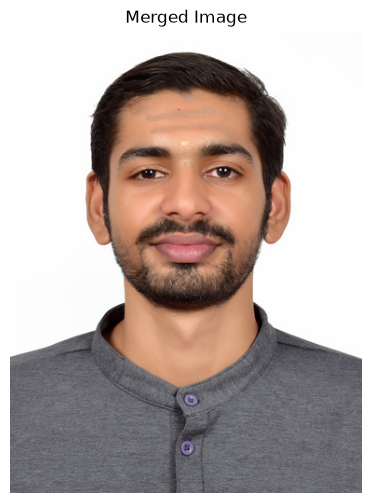

In [13]:
# Split the RGB image into four parts
height, width, _ = image_rgb.shape
mid_y, mid_x = height // 2, width // 2

top_left = image_rgb[:mid_y, :mid_x]
top_right = image_rgb[:mid_y, mid_x:]
bottom_left = image_rgb[mid_y:, :mid_x]
bottom_right = image_rgb[mid_y:, mid_x:]

# Visualize the four parts
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, part, title in zip(
    axes.ravel(),
    [top_left, top_right, bottom_left, bottom_right],
    ["Top Left", "Top Right", "Bottom Left", "Bottom Right"]
):
    ax.imshow(part)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Merge the four parts back into the original image
top_row = cv2.hconcat([top_left, top_right])
bottom_row = cv2.hconcat([bottom_left, bottom_right])
merged_image = cv2.vconcat([top_row, bottom_row])

# Visualize the merged image
plt.figure(figsize=(8, 6))
plt.imshow(merged_image)
plt.title("Merged Image")
plt.axis("off")
plt.show()

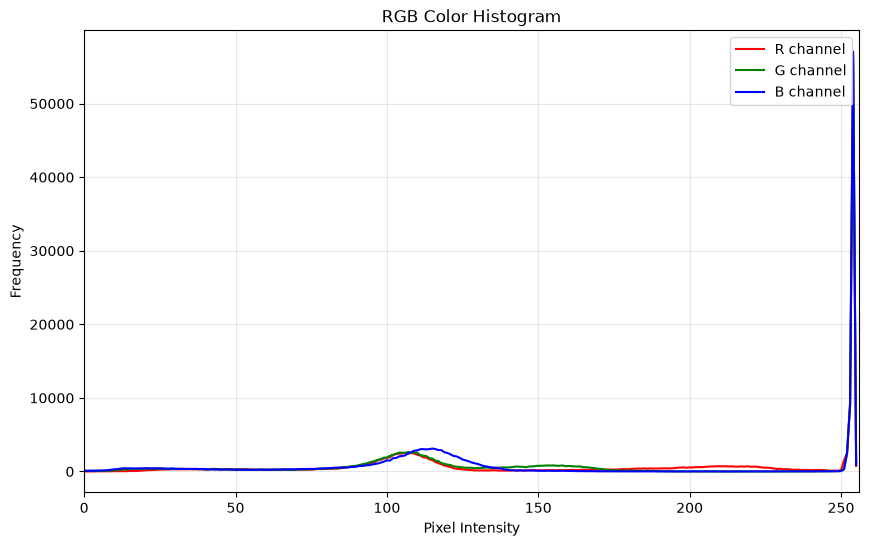

In [14]:
# Compute and plot the histogram for each RGB channel
colors = ("red", "green", "blue")
channel_names = ("R", "G", "B")

plt.figure(figsize=(10, 6))

for channel, color, name in zip(range(3), colors, channel_names):
    histogram = cv2.calcHist([image_rgb], [channel], None, [256], [0, 256])
    plt.plot(histogram, color=color, label=f"{name} channel")

plt.title("RGB Color Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

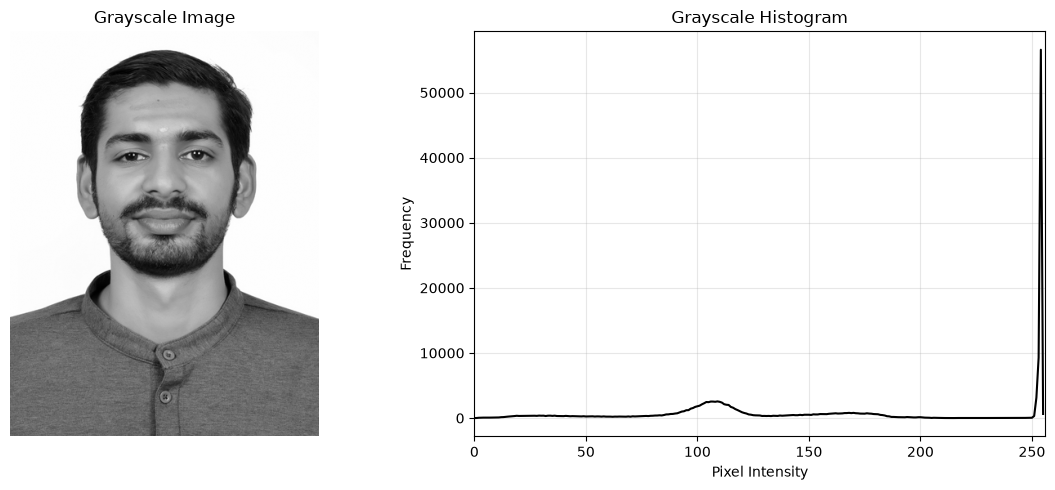

In [15]:
# Convert the RGB image to grayscale
gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# Compute the grayscale histogram
gray_histogram = cv2.calcHist([gray_image], [0], None, [256], [0, 256])

# Plot the grayscale image and histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(gray_image, cmap="gray")
axes[0].set_title("Grayscale Image")
axes[0].axis("off")

axes[1].plot(gray_histogram, color="black")
axes[1].set_title("Grayscale Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim([0, 256])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Original image shape: (496, 378, 3)
Zoomed-in image shape: (992, 756, 3)
Zoomed-out image shape: (248, 189, 3)


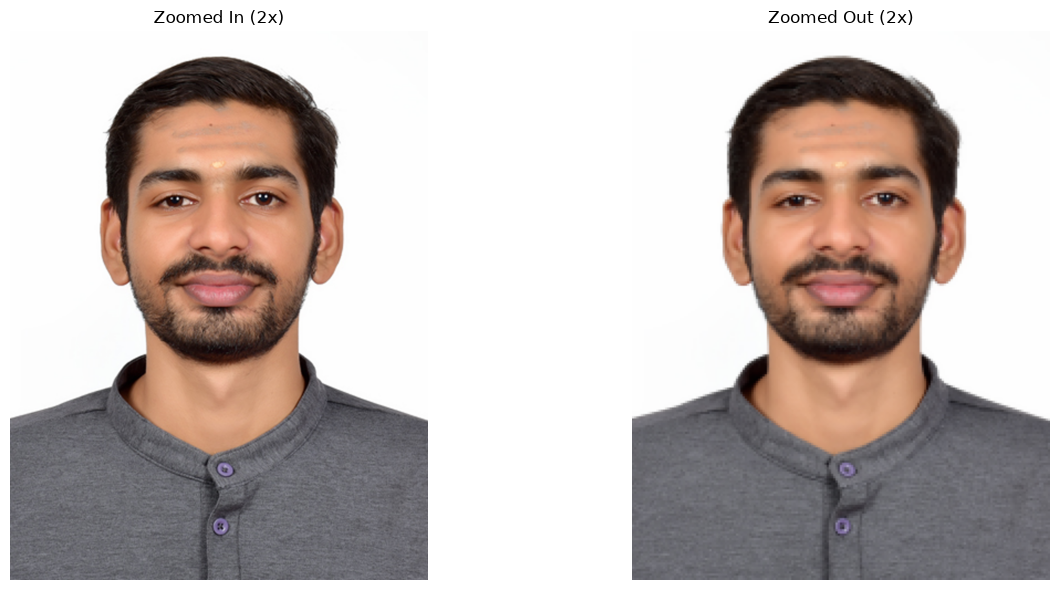

In [16]:
# Zoom in by 2x
zoomed_image = cv2.resize(
    image_rgb,
    None,
    fx=2,
    fy=2,
    interpolation=cv2.INTER_CUBIC
)

# Zoom out by 2x
zoomed_out_image = cv2.resize(
    image_rgb,
    None,
    fx=0.5,
    fy=0.5,
    interpolation=cv2.INTER_AREA
)

# Print image shapes
print("Original image shape:", image_rgb.shape)
print("Zoomed-in image shape:", zoomed_image.shape)
print("Zoomed-out image shape:", zoomed_out_image.shape)

# Visualize both images side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(zoomed_image)
axes[0].set_title("Zoomed In (2x)")
axes[0].axis("off")

axes[1].imshow(zoomed_out_image)
axes[1].set_title("Zoomed Out (2x)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Original image shape: (496, 378, 3)
Pyramid level 1 shape: (248, 189, 3)
Pyramid level 2 shape: (124, 95, 3)
Pyramid level 3 shape: (62, 48, 3)


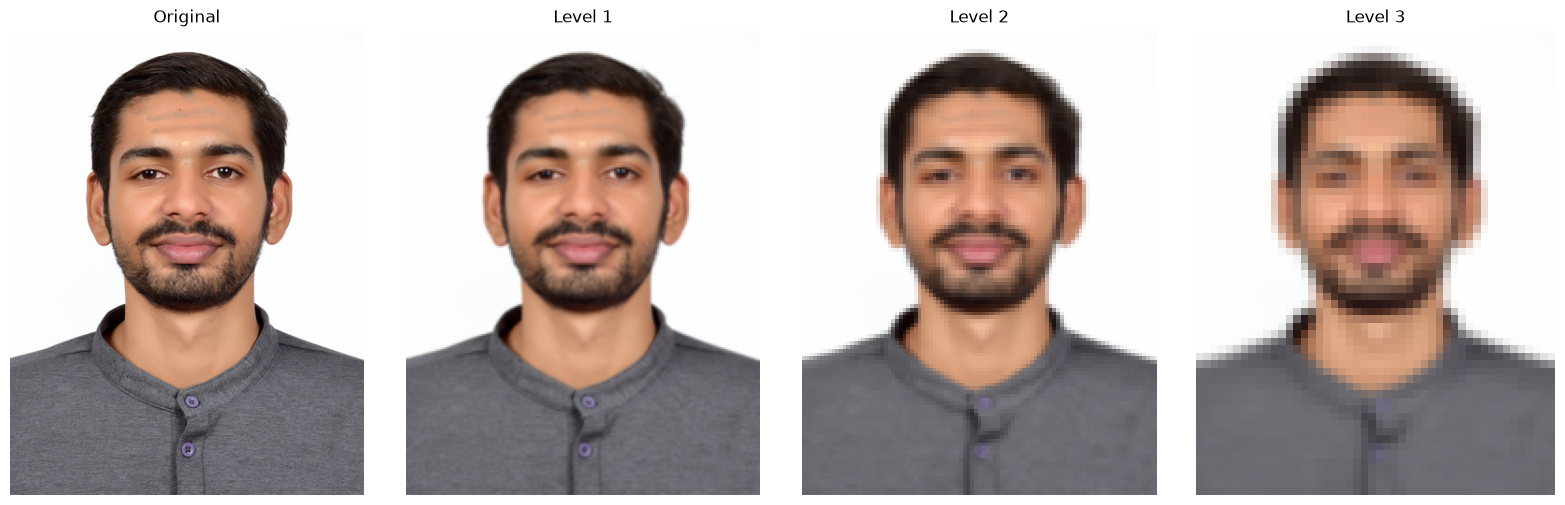

In [17]:
# Build an image pyramid using cv2.pyrDown()
pyramid_level1 = cv2.pyrDown(image_rgb)
pyramid_level2 = cv2.pyrDown(pyramid_level1)
pyramid_level3 = cv2.pyrDown(pyramid_level2)

# Print dimensions
print("Original image shape:", image_rgb.shape)
print("Pyramid level 1 shape:", pyramid_level1.shape)
print("Pyramid level 2 shape:", pyramid_level2.shape)
print("Pyramid level 3 shape:", pyramid_level3.shape)

# Visualize the image pyramid
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

images = [image_rgb, pyramid_level1, pyramid_level2, pyramid_level3]
titles = ["Original", "Level 1", "Level 2", "Level 3"]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()